In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.seed import set_seed
from src.pipeline.missing_value import CJ_MissingValue, JH_MissingValue, JH_train_stats
from src.pipeline.outlier_control import OutlierControl
from src.pipeline.features import FeatureCreate
set_seed(42)


In [77]:
data = pd.read_excel('../../data/dataset.xlsx')

X = data.drop('Churn', axis = 1)
y = data['Churn']

In [ ]:
set_seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
pd.concat(
    [
        pd.concat([X_train, y_train], axis=1).assign(split="train"),
        pd.concat([X_test, y_test], axis=1).assign(split="test"),
    ],
    ignore_index=True,
).to_csv("../../data/MLP_train_test_split.csv", index=False, encoding="utf-8-sig")

In [79]:
CJ_SPECS = (
    ("Tenure", "NumberOfAddress", 5),
    ("DaySinceLastOrder", ["PreferedOrderCat", "PreferredLoginDevice"], 10),
    ("OrderCount", ["PreferedOrderCat", "PreferredPaymentMode"], 10),
    ("OrderAmountHikeFromlastYear", "PreferedOrderCat", 3),
)

for column_name, group_by_columns, minimum_group_size in CJ_SPECS:
    # 이 컬럼 전체의 중앙값 (작은 그룹일 때 쓰는 기본값)
    median_of_entire_train = X_train[column_name].median()

    CJ_MissingValue(
        X_train,
        col=column_name,
        group_cols=group_by_columns,
        min_group_size=minimum_group_size,
        train_median=median_of_entire_train,
        test_df=X_test,
    )

# 결측 JH: train에서만 통계 계산 → train·test 동일 인자로 채움
jh_stats = JH_train_stats(X_train)

for dataframe in (X_train, X_test):
    JH_MissingValue(dataframe, **jh_stats)

In [80]:
# 이상치 처리 (train/test 각각) — log/clip 변환 후 원본 수치 컬럼 제거
cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']
OutlierControl(X_train, cols)
OutlierControl(X_test, cols)

,CustomerID,PreferredLoginDevice,CityTier,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,Tenure_log,WarehouseToHome_log,DaySinceLastOrder_clip,CashbackAmount_clip
4006,54007,Computer,3,Debit Card,Male,4.0,4,Laptop & Accessory,1,Married,3,0,21.0,6.0,8.0,2.890372,2.302585,8.0,181.75
1969,51970,Mobile Phone,3,E wallet,Female,3.0,4,Fashion,1,Married,8,1,18.0,0.0,1.0,3.295837,2.639057,3.0,209.34
4235,54236,Mobile Phone,1,Debit Card,Female,4.0,4,Laptop & Accessory,1,Single,3,0,24.0,2.0,2.0,1.791759,2.772589,9.0,169.24
105,50106,Phone,1,Debit Card,Female,2.0,4,Mobile,2,Single,8,0,15.0,0.0,2.0,3.258097,2.197225,2.0,132.12
2295,52296,Computer,3,Debit Card,Female,2.0,3,Fashion,3,Married,2,1,19.0,8.0,9.0,1.609438,2.197225,6.0,198.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4362,54363,Computer,1,Credit Card,Male,3.0,4,Mobile Phone,3,Married,3,1,18.0,3.0,3.0,2.197225,2.890372,1.0,163.15
2487,52488,Mobile Phone,1,Credit Card,Female,2.0,5,Laptop & Accessory,5,Single,2,1,14.0,0.0,1.0,2.944439,2.484907,4.0,157.69
5063,55064,Mobile Phone,1,Debit Card,Male,3.0,4,Laptop & Accessory,1,Married,3,1,12.0,2.0,2.0,1.386294,2.708050,1.0,191.23
1958,51959,Phone,2,UPI,Male,2.0,3,Mobile Phone,1,Married,1,0,19.0,1.0,1.0,2.079442,2.302585,2.0,137.37


In [81]:
set_seed(42)

X_train = FeatureCreate(X_train)
_mof_mean = X_train['MonthlyOrderFreq'].mean()
X_test = FeatureCreate(X_test, train_monthly_freq_mean=_mof_mean)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

X_train = X_train.drop(columns=['CustomerID'], errors='ignore')
X_test = X_test.drop(columns=['CustomerID'], errors='ignore')

In [82]:
set_seed(42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [83]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    activation='relu',           
    solver='adam',               
    max_iter=500,                
    random_state=42
)



In [84]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'hidden_layer_sizes': [(64, 32), (100,), (50, 50)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

set_seed(42)
grid = GridSearchCV(MLPClassifier(max_iter=500, random_state=42), param_grid, cv=3, scoring='f1', n_jobs=1)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print(f"최적의 파라미터: {grid.best_params_}")


최적의 파라미터: {'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}


In [85]:
best_mlp = grid.best_estimator_

In [86]:
pd_pb = best_mlp.predict_proba(X_test_scaled)

F1 (threshold=0.5): 0.8168
ROC-AUC: 0.9688


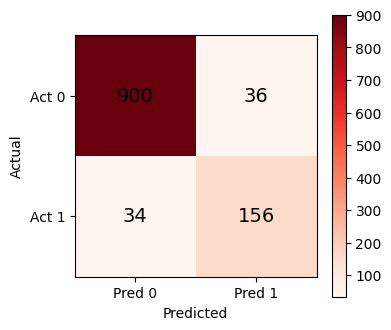

In [87]:
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

y_prob = pd_pb[:, 1]
THRESH = 0.5
y_pred = (y_prob >= THRESH).astype(int)

f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"F1 (threshold={THRESH}): {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap="Reds")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Act 0", "Act 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()



In [88]:
from pathlib import Path
import joblib

MODEL_DIR = Path("../../models").resolve()
MODEL_DIR.mkdir(parents=True, exist_ok=True)
out_path = MODEL_DIR / "MLP_model.joblib"

artifact = {"scaler": scaler, "model": best_mlp}
joblib.dump(artifact, out_path)
print(f"Saved: {out_path}")



Saved: C:\dev\project\SKN27-2nd-4TEAM\models\MLP_model.joblib


  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Playdata\AppData\Local\Temp\ipykernel_3648\2564819097.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled[:50])


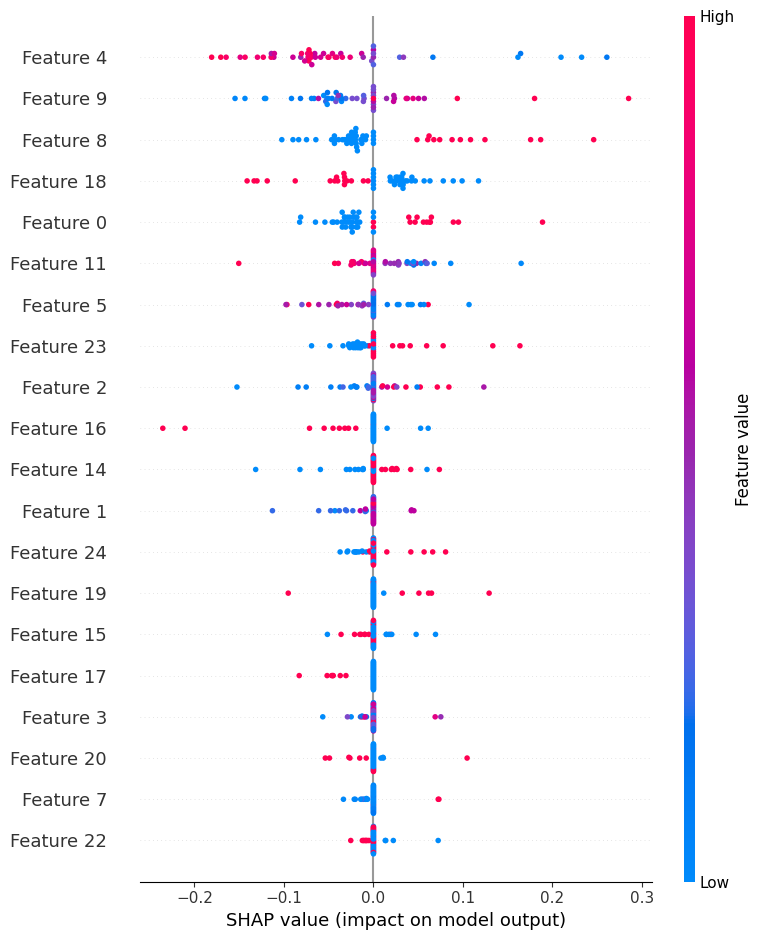

In [89]:
import shap

explainer = shap.KernelExplainer(best_mlp.predict, shap.sample(X_train_scaled, 50))
shap_values = explainer.shap_values(X_test_scaled[:50])
shap.summary_plot(shap_values, X_test_scaled[:50])